In [16]:
import pandas as pd

data_raw = pd.read_csv('data/london_houses_transformed.csv')

# SEPARATE FEATURES FROM THE TARGET
X = data_raw.drop('price', axis = 1)
y = data_raw['price']

In [17]:
X[:5]

,area_sqft,bedrooms,bathrooms,receptions,type_Bungalow,type_Duplex,type_Flat / Apartment,type_House,type_Mews,type_New development,...,pc_W1U,pc_W1W,pc_W2,pc_W3,pc_W4,pc_W5,pc_W6,pc_W8,pc_W9,pc_WD19
0,10100,10,10,10,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2832,3,3,3,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4876,6,6,6,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5184,5,5,5,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2782,2,2,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [18]:
y[:3]

0    9975000
1    9950000
2    9950000
Name: price, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split

# DATA SPLIT 80/20
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=15)

In [47]:
from sklearn.preprocessing import StandardScaler

# NORMALISE
scaler_X = StandardScaler().fit(X_train_raw)
scaler_y = StandardScaler().fit(y_train_raw.values.reshape(-1, 1))

In [48]:
# SAVING THIS FOR DE-NORMALISATION LATER
price_mean = scaler_y.mean_[0]
price_std  = scaler_y.scale_[0]

price_mean, price_std

(np.float64(1694144.2489098837), np.float64(1507930.4570559901))

In [49]:
import torch

# TENSOR
X_train = torch.FloatTensor(scaler_X.transform(X_train_raw))
X_test  = torch.FloatTensor(scaler_X.transform(X_test_raw))
y_train = torch.FloatTensor(scaler_y.transform(y_train_raw.values.reshape(-1, 1)))
y_test  = torch.FloatTensor(scaler_y.transform(y_test_raw.values.reshape(-1, 1)))

In [50]:
from torch import nn
import torch.nn.functional as F


class Model(nn.Module):
    def __init__(self, in_features=87, h1=64, h2=32, output_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, output_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

model = Model()

In [51]:
model

Model(
  (fc1): Linear(in_features=87, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)

In [52]:
epochs = 100
learning_rate = 0.01
torch.manual_seed(15)

losses = []
optimiser = torch.optim.Adam(model.parameters(), learning_rate)
loss_func = nn.MSELoss()

for i in range(epochs):
    optimiser.zero_grad()

    y_pred = model.forward(X_train)

    # MEASURE THE LOSS/ERROR
    loss = loss_func(y_pred, y_train)

    # (OPTIONAL) ADDING LOSS FROM THE CURRENT EPOCH
    losses.append(loss.detach().numpy())

    # (OPTIONAL) PRINTING LOSS EVERY 500th EPOCH
    if i % 10 == 0:
        print(f'Epoch: {i} loss: {loss}')

    # CLEAR GRADIENTS FROM PREVIOUS STEP
    optimiser.zero_grad()
    # BACKPROPAGATION
    loss.backward()
    # UPDATE WEIGHTS
    optimiser.step()

# SAVE OUR FINAL MODEL
torch.save(model.state_dict(), 'model.pth')

Epoch: 0 loss: 1.0348366498947144
Epoch: 10 loss: 0.313341349363327
Epoch: 20 loss: 0.20293281972408295
Epoch: 30 loss: 0.14354410767555237
Epoch: 40 loss: 0.11358023434877396
Epoch: 50 loss: 0.0981246829032898
Epoch: 60 loss: 0.08964795619249344
Epoch: 70 loss: 0.08335372060537338
Epoch: 80 loss: 0.07895088940858841
Epoch: 90 loss: 0.07559282332658768


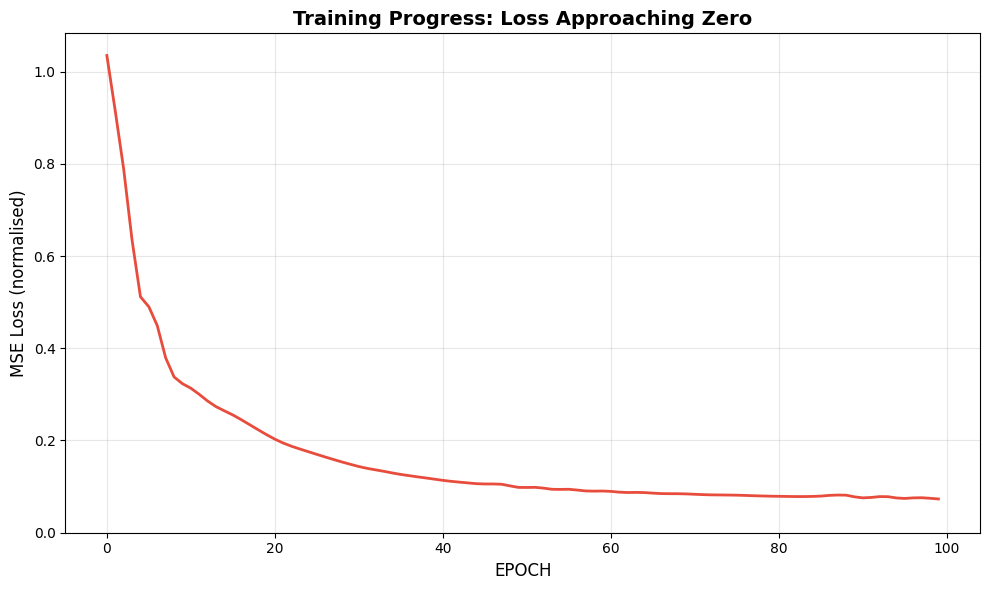

In [53]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, color='#e74c3c')
plt.xlabel('EPOCH', fontsize=12)
plt.ylabel('MSE Loss (normalised)', fontsize=12)
plt.title('Training Progress: Loss Approaching Zero', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# TELLS PYTORCH WE ARE IN INFERENCE MODE
model.eval()
with torch.no_grad():
    predictions = model(X_test)

    # DENORMALISE BACK TO REAL PRICES:
    predictions_real = predictions * price_std + price_mean
    Y_test_real = y_test * price_std + price_mean

    print("\nTEST PREDICTIONS (UNSEEN DATA):")
    mae = mean_absolute_error(Y_test_real, predictions_real)
    mape = mean_absolute_percentage_error(Y_test_real, predictions_real) * 100

    # CALCULATE PERCENTAGE ERRORS
    pct_errors = torch.abs((Y_test_real - predictions_real) / Y_test_real) * 100

    within_10 = (pct_errors <= 10).sum().item()
    within_20 = (pct_errors <= 20).sum().item()
    total = len(Y_test_real)

print(f"\nOverall performance:")
print(f"  MAE:  £{mae:,.0f}")
print(f"  MAPE: {mape:.1f}%")
print(f"  Within 10%: {within_10}/{total} ({within_10/total*100:.0f}%)")
print(f"  Within 20%: {within_20}/{total} ({within_20/total*100:.0f}%)")


TEST PREDICTIONS (UNSEEN DATA):

Overall performance:
  MAE:  £346,712
  MAPE: 20.0%
  Within 10%: 247/689 (36%)
  Within 20%: 455/689 (66%)
